# EDA & Pipeline MLOps — Système de Recommandation de Films
**Moussa Seye — EPT DIC3 | MLOps**

Dataset : MovieLens ml-latest-small (GroupLens Research)

Ce notebook couvre l'intégralité du pipeline, de bout en bout :
```
Téléchargement  →  data/raw/
                →  data/interim/   (nettoyage, filtrage)
                →  data/processed/ (feature engineering)
                →  EDA + MLflow
```
Les fonctions viennent de `src/data_loader.py` et `src/features.py` — le notebook les appelle explicitement pour rendre chaque étape visible.

## 0. Imports & Configuration

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

PROJECT_DIR = Path.cwd().parent
sys.path.insert(0, str(PROJECT_DIR))

from settings.params import (
    MLFLOW_TRACKING_URI, EXPERIMENT_NAME,
    DATA_DIR_RAW, DATA_DIR_INTERIM, DATA_DIR_PROCESSED,
    MODEL_PARAMS, SEED,
)
from src.data_loader import (
    download_movielens,
    process_ratings, process_movies, process_tags,
    load_ratings, load_movies, load_tags,
    dataset_summary,
)
from src.features import (
    build_surprise_dataset,
    build_user_item_matrix,
    build_user_features,
    build_item_features,
    encode_genres,
)

log_fmt = "<green>{time:YYYY-MM-DD HH:mm:ss!UTC}</green> | <level>{level: <8}</level> | {message}"
logger.remove()
logger.add(sys.stderr, format=log_fmt, level="INFO")

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

print(f"raw/       : {DATA_DIR_RAW}")
print(f"interim/   : {DATA_DIR_INTERIM}")
print(f"processed/ : {DATA_DIR_PROCESSED}")

raw/       : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/raw
interim/   : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/interim
processed/ : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/processed


## 1. Pipeline de données
### Étape 1 — Téléchargement (→ `data/raw/`)

La fonction `download_movielens()` télécharge le fichier ZIP depuis GroupLens Research
et l'extrait dans `data/raw/ml-latest-small/`.

> Si le dossier existe déjà, le téléchargement est sauté (idempotent).

In [2]:
# Télécharge et extrait le dataset (skip si déjà présent)
download_movielens(force=False)

raw_files = list((DATA_DIR_RAW / "ml-latest-small").iterdir())
print("Fichiers dans data/raw/ml-latest-small/ :")
for f in sorted(raw_files):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<20}  {size_kb:>8.1f} KB")

2026-06-10 09:58:59 | INFO     | Dataset brut déjà présent : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/raw/ml-latest-small


Fichiers dans data/raw/ml-latest-small/ :
  README.txt                 8.1 KB
  links.csv                193.3 KB
  movies.csv               482.8 KB
  ratings.csv             2425.5 KB
  tags.csv                 115.9 KB


### Étape 2 — Nettoyage & Filtrage (`raw` → `data/interim/`)

**Transformations appliquées :**
- `ratings` : filtre les utilisateurs et les films ayant < `MIN_RATINGS=5` notes
  *(cold-start mitigation — on retire les entités trop rares pour être utiles)*
- `movies` : extraction de l'année depuis le titre `"Toy Story (1995)"`,
  nettoyage du titre, genres string → liste Python
- Sauvegarde en **Parquet** (format colonnaire, 10× plus rapide que CSV au chargement)

> Les fichiers `data/raw/` ne sont **jamais modifiés** — c'est la règle fondamentale
> du pipeline MLOps : les données brutes sont immuables.

In [3]:
# Ratings : filtrage MIN_RATINGS
ratings_raw = pd.read_csv(DATA_DIR_RAW / "ml-latest-small" / "ratings.csv")
ratings_raw.columns = ratings_raw.columns.str.lower()
print(f"Brut  : {len(ratings_raw):>7,} notes | "
      f"{ratings_raw['userid'].nunique()} users | "
      f"{ratings_raw['movieid'].nunique()} films")

ratings = process_ratings(force=False)
print(f"Filtré: {len(ratings):>7,} notes | "
      f"{ratings['userid'].nunique()} users | "
      f"{ratings['movieid'].nunique()} films")
print(f"Conservé : {len(ratings)/len(ratings_raw)*100:.1f}%")

2026-06-10 09:58:59 | INFO     | Interim ratings déjà présent : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/interim/ratings_filtered.parquet


Brut  : 100,836 notes | 610 users | 9724 films
Filtré:  90,274 notes | 610 users | 3650 films
Conservé : 89.5%


In [4]:
# Movies : extraction année + nettoyage genres
movies = process_movies(force=False)
print(f"Films chargés : {len(movies):,}")
print(f"Années        : {movies['year'].dropna().astype(int).min()} – "
      f"{movies['year'].dropna().astype(int).max()}")
print(f"Films sans année : {movies['year'].isna().sum()}")
movies[["movieid", "title", "title_clean", "year", "genres_list"]].head()

2026-06-10 09:58:59 | INFO     | Interim movies déjà présent : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/interim/movies_clean.parquet


Films chargés : 9,742
Années        : 1902 – 2018
Films sans année : 24


,movieid,title,title_clean,year,genres_list
0,1,Toy Story (1995),Toy Story,1995.0,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Jumanji,1995.0,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Grumpier Old Men,1995.0,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Waiting to Exhale,1995.0,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Father of the Bride Part II,1995.0,[Comedy]


In [5]:
# Tags
tags = process_tags(force=False)
print(f"Tags chargés : {len(tags):,}")

# Vérifier les fichiers interim générés
print("\nFichiers dans data/interim/ :")
for f in sorted(DATA_DIR_INTERIM.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<35}  {size_kb:>8.1f} KB")

2026-06-10 09:58:59 | INFO     | Interim tags déjà présent : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/interim/tags_clean.parquet


Tags chargés : 3,683

Fichiers dans data/interim/ :
  movies_clean.parquet                    475.2 KB
  ratings_filtered.parquet                705.6 KB
  tags_clean.parquet                       55.4 KB


### Étape 3 — Feature Engineering (`interim` → `data/processed/`)

À partir des données nettoyées, on construit les **matrices de features** :

| Fichier | Contenu |
|---|---|
| `user_item_matrix.parquet` | Pivot table users × films (sparse) |
| `user_features.parquet` | Statistiques par utilisateur (n_ratings, mean, std…) |
| `item_features.parquet` | Statistiques par film + métadonnées |
| `genre_matrix.parquet` | One-hot encoding des genres |

On construit aussi le **Dataset Surprise** (format requis par scikit-surprise pour l'entraînement).

In [6]:
# Matrice user-item (sparse : 95,95% de NaN)
user_item_matrix = build_user_item_matrix(ratings, save=True)
print(f"Matrice user-item : {user_item_matrix.shape}")

2026-06-10 09:58:59 | INFO     | Matrice user-item déjà présente : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/processed/user_item_matrix.parquet


Matrice user-item : (610, 3650)


In [7]:
# Features utilisateurs
user_feats = build_user_features(ratings, save=True)
print(f"User features : {user_feats.shape}")
user_feats.head()

2026-06-10 09:59:00 | INFO     | User features déjà présentes : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/processed/user_features.parquet


User features : (610, 6)


,userid,user_n_ratings,user_mean_rating,user_std_rating,user_min_rating,user_max_rating
0,1,227,4.3612,0.8048,1.0,5.0
1,2,27,3.9815,0.7136,2.5,5.0
2,3,28,1.4821,1.6693,0.5,5.0
3,4,199,3.5427,1.3360,1.0,5.0
4,5,44,3.6364,0.9904,1.0,5.0


In [8]:
# Features films
item_feats = build_item_features(ratings, movies, save=True)
print(f"Item features : {item_feats.shape}")
item_feats.head()

2026-06-10 09:59:00 | INFO     | Item features déjà présentes : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/processed/item_features.parquet


Item features : (3650, 8)


,movieid,item_n_ratings,item_mean_rating,item_std_rating,title_clean,year,genres,genres_list
0,1,215,3.9209,0.8349,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,110,3.4318,0.8817,Jumanji,1995.0,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,3,52,3.2596,1.0548,Grumpier Old Men,1995.0,Comedy|Romance,"[Comedy, Romance]"
3,4,7,2.3571,0.8522,Waiting to Exhale,1995.0,Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
4,5,49,3.0714,0.9071,Father of the Bride Part II,1995.0,Comedy,[Comedy]


In [9]:
# Matrice de genres (one-hot)
genre_matrix = encode_genres(movies, save=True)
genres = [c for c in genre_matrix.columns if c not in ["movieid", "title_clean"]]
print(f"Genre matrix : {genre_matrix.shape} — {len(genres)} genres")
print("Genres :", genres)

2026-06-10 09:59:00 | INFO     | Genre matrix déjà présente : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/processed/genre_matrix.parquet


Genre matrix : (9742, 22) — 20 genres
Genres : ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [10]:
# Dataset Surprise (pour l'entraînement des modèles)
surprise_ds = build_surprise_dataset(ratings)
print("Dataset Surprise prêt pour l'entraînement")

# Résumé des fichiers processed
print("\nFichiers dans data/processed/ :")
for f in sorted(DATA_DIR_PROCESSED.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<35}  {size_kb:>8.1f} KB")

2026-06-10 09:59:00 | INFO     | Dataset Surprise construit (90,274 notes)


Dataset Surprise prêt pour l'entraînement

Fichiers dans data/processed/ :
  genre_matrix.parquet                    255.6 KB
  item_features.parquet                   137.1 KB
  user_features.parquet                    19.0 KB
  user_item_matrix.parquet               2554.3 KB


## 2. EDA — Analyse Exploratoire

### 2.1 Métriques descriptives + MLflow logging

In [11]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

summary = dataset_summary(ratings, movies)

with mlflow.start_run(run_name="EDA_dataset_summary"):
    mlflow.log_metrics({k: v for k, v in summary.items() if isinstance(v, (int, float))})
    logger.success("Métriques EDA loggées dans MLflow")

pd.DataFrame([summary]).T.rename(columns={0: "Valeur"})

2026-06-10 09:59:00 | INFO     | Résumé dataset : {'n_ratings': 90274, 'n_users': 610, 'n_items': 3650, 'density_pct': 4.0545, 'avg_rating': 3.5374, 'std_rating': 1.0299, 'n_genres': 20}
2026-06-10 09:59:00 | SUCCESS  | Métriques EDA loggées dans MLflow


,Valeur
n_ratings,90274.0000
n_users,610.0000
n_items,3650.0000
density_pct,4.0545
avg_rating,3.5374
std_rating,1.0299
n_genres,20.0000


### 2.2 Distribution des notes

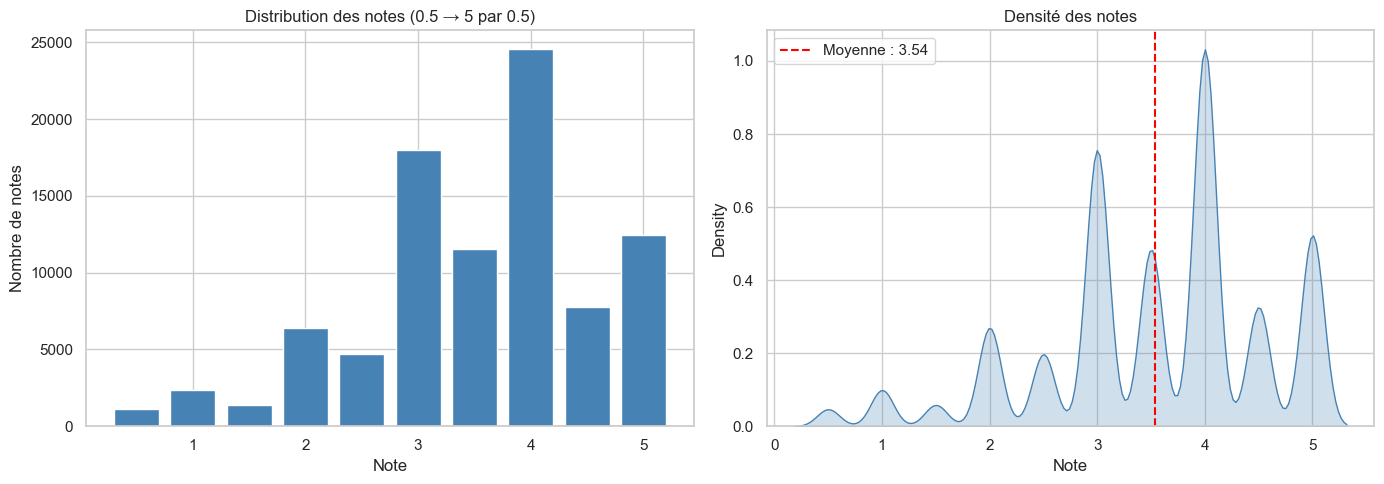

count    90274.000
mean         3.537
std          1.030
min          0.500
25%          3.000
50%          3.500
75%          4.000
max          5.000
Name: rating, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = ratings["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color="steelblue", width=0.4, edgecolor="white")
axes[0].set_title("Distribution des notes (0.5 → 5 par 0.5)")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre de notes")

sns.kdeplot(ratings["rating"], ax=axes[1], fill=True, color="steelblue")
axes[1].axvline(ratings["rating"].mean(), color="red", linestyle="--",
                label=f"Moyenne : {ratings['rating'].mean():.2f}")
axes[1].set_title("Densité des notes")
axes[1].set_xlabel("Note")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "distribution_notes.png", dpi=150, bbox_inches="tight")
plt.show()
print(ratings["rating"].describe().round(3))

### 2.3 Activité utilisateurs et films

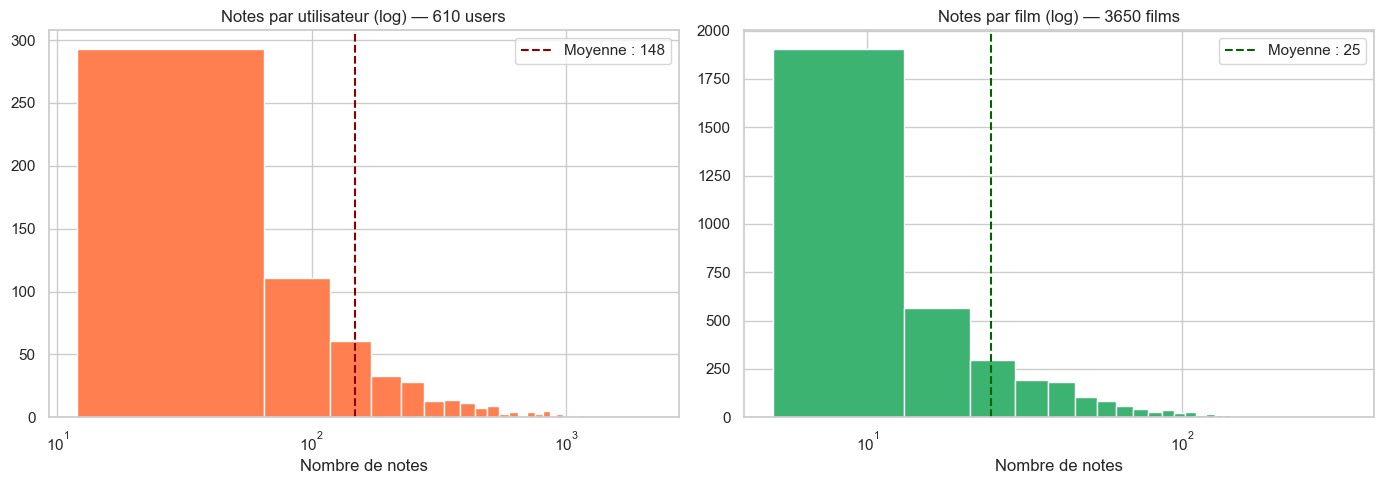

Users — min:12 max:2132 médiane:68
Films — min:5 max:329 médiane:13


In [13]:
user_counts = ratings.groupby("userid").size().sort_values(ascending=False)
item_counts = ratings.groupby("movieid").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_counts, bins=40, color="coral", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title(f"Notes par utilisateur (log) — {len(user_counts)} users")
axes[0].set_xlabel("Nombre de notes")
axes[0].axvline(user_counts.mean(), color="darkred", linestyle="--",
                label=f"Moyenne : {user_counts.mean():.0f}")
axes[0].legend()

axes[1].hist(item_counts, bins=40, color="mediumseagreen", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title(f"Notes par film (log) — {len(item_counts)} films")
axes[1].set_xlabel("Nombre de notes")
axes[1].axvline(item_counts.mean(), color="darkgreen", linestyle="--",
                label=f"Moyenne : {item_counts.mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "activity_users_items.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Users — min:{user_counts.min()} max:{user_counts.max()} médiane:{user_counts.median():.0f}")
print(f"Films — min:{item_counts.min()} max:{item_counts.max()} médiane:{item_counts.median():.0f}")

### 2.4 Sparsité de la matrice user-item

Dimensions : 610 users × 3650 films
Notes renseignées : 90,274 / 2,226,500
Sparsité   : 95.95%
Densité    : 4.05%


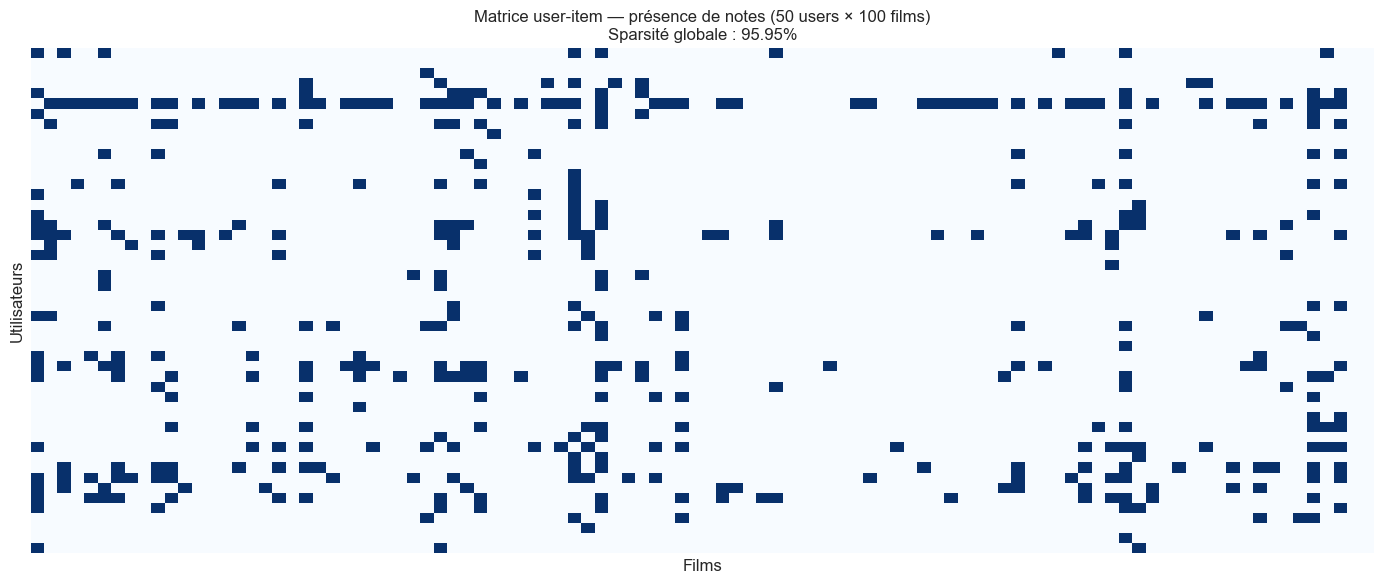

In [14]:
n_users, n_items = user_item_matrix.shape
n_filled = user_item_matrix.notna().sum().sum()
sparsity = 1 - n_filled / (n_users * n_items)

print(f"Dimensions : {n_users} users × {n_items} films")
print(f"Notes renseignées : {n_filled:,} / {n_users * n_items:,}")
print(f"Sparsité   : {sparsity:.2%}")
print(f"Densité    : {1-sparsity:.2%}")

sample = user_item_matrix.iloc[:50, :100]
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(sample.notna().astype(int), ax=ax,
            cmap="Blues", cbar=False, xticklabels=False, yticklabels=False)
ax.set_title(f"Matrice user-item — présence de notes (50 users × 100 films)\n"
             f"Sparsité globale : {sparsity:.2%}")
ax.set_xlabel("Films")
ax.set_ylabel("Utilisateurs")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "sparsity_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.5 Analyse des genres

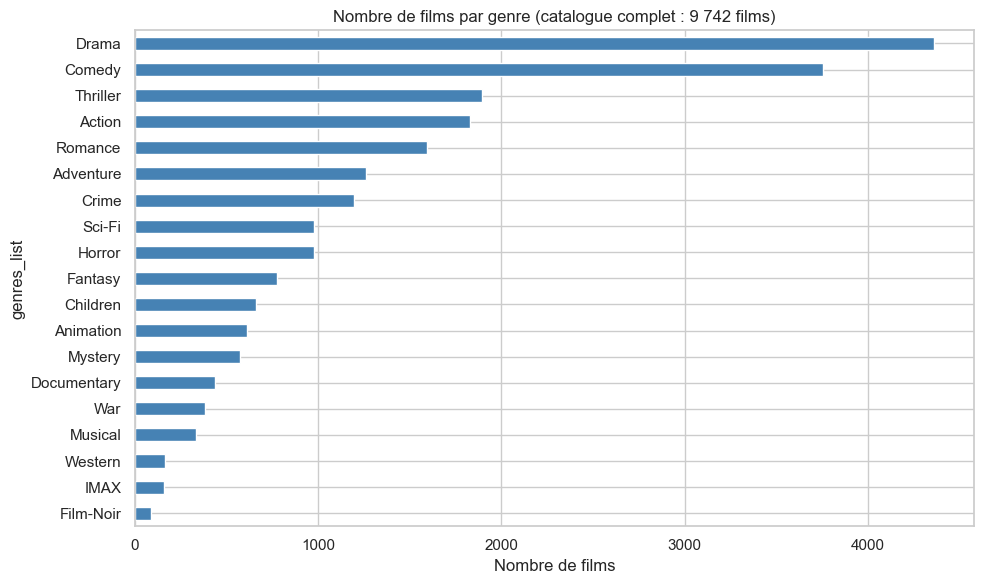

In [15]:
genre_counts = (
    movies["genres_list"].explode()
    .value_counts()
    .drop("(no genres listed)", errors="ignore")
)

fig, ax = plt.subplots(figsize=(10, 6))
genre_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Nombre de films par genre (catalogue complet : 9 742 films)")
ax.set_xlabel("Nombre de films")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "genre_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

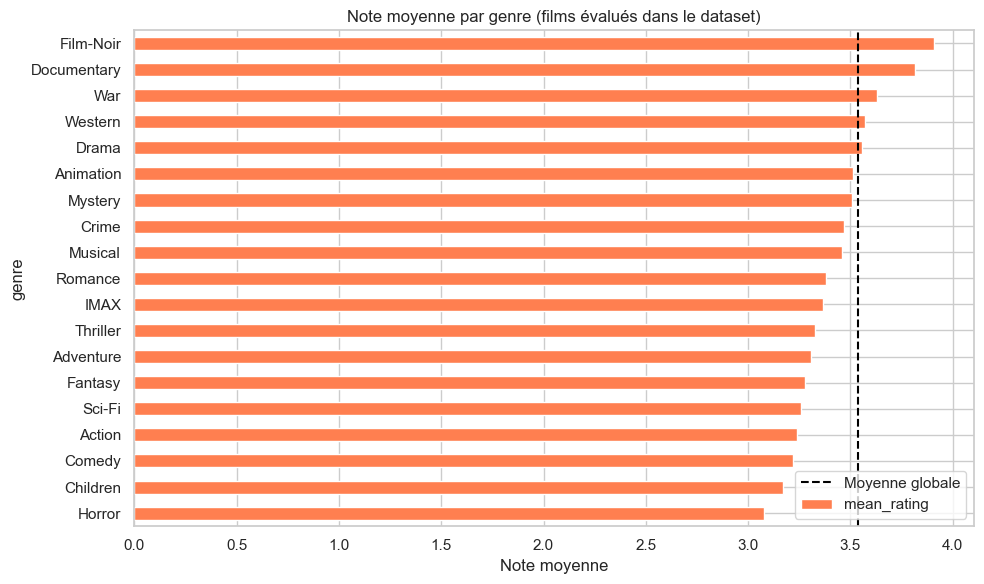

,mean_rating,n_films
genre,,
Film-Noir,3.909,34
Documentary,3.814,57
War,3.631,156
Western,3.573,69
Drama,3.556,1597
Animation,3.513,227
Mystery,3.507,258
Crime,3.467,522
Musical,3.458,145


In [16]:
genre_ratings = (
    item_feats[["genres_list", "item_mean_rating", "item_n_ratings"]]
    .explode("genres_list")
    .rename(columns={"genres_list": "genre"})
    .query("genre != '(no genres listed)'")
    .groupby("genre")
    .agg(mean_rating=("item_mean_rating", "mean"), n_films=("item_mean_rating", "count"))
    .sort_values("mean_rating", ascending=False)
    .round(3)
)

fig, ax = plt.subplots(figsize=(10, 6))
genre_ratings["mean_rating"].sort_values().plot(kind="barh", ax=ax, color="coral")
ax.axvline(ratings["rating"].mean(), color="black", linestyle="--", label="Moyenne globale")
ax.set_title("Note moyenne par genre (films évalués dans le dataset)")
ax.set_xlabel("Note moyenne")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "genre_ratings.png", dpi=150, bbox_inches="tight")
plt.show()
display(genre_ratings)

### 2.6 Features utilisateurs

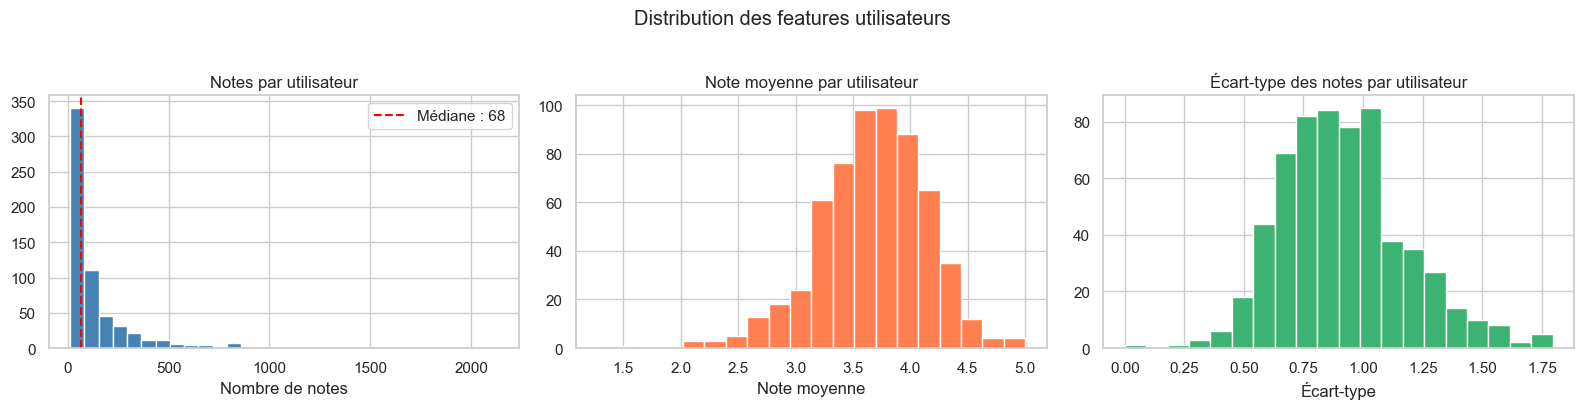

,userid,user_n_ratings,user_mean_rating,user_std_rating,user_min_rating,user_max_rating
count,610.000,610.000,610.000,610.000,610.000,610.000
mean,305.500,147.990,3.668,0.917,1.348,4.955
std,176.236,216.882,0.484,0.262,0.847,0.194
min,1.000,12.000,1.275,0.000,0.500,2.500
25%,153.250,34.000,3.380,0.725,0.500,5.000
50%,305.500,68.000,3.698,0.888,1.000,5.000
75%,457.750,159.000,4.000,1.063,2.000,5.000
max,610.000,2132.000,5.000,1.795,5.000,5.000


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(user_feats["user_n_ratings"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Notes par utilisateur")
axes[0].set_xlabel("Nombre de notes")
axes[0].axvline(user_feats["user_n_ratings"].median(), color="red", linestyle="--",
                label=f"Médiane : {user_feats['user_n_ratings'].median():.0f}")
axes[0].legend()

axes[1].hist(user_feats["user_mean_rating"], bins=20, color="coral", edgecolor="white")
axes[1].set_title("Note moyenne par utilisateur")
axes[1].set_xlabel("Note moyenne")

axes[2].hist(user_feats["user_std_rating"].dropna(), bins=20,
             color="mediumseagreen", edgecolor="white")
axes[2].set_title("Écart-type des notes par utilisateur")
axes[2].set_xlabel("Écart-type")

plt.suptitle("Distribution des features utilisateurs", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "user_features.png", dpi=150, bbox_inches="tight")
plt.show()
display(user_feats.describe().round(3))

### 2.7 Top films les mieux notés (≥ 50 notes)

In [18]:
top_films = (
    item_feats[item_feats["item_n_ratings"] >= 50]
    .sort_values("item_mean_rating", ascending=False)
    .head(15)[["title_clean", "year", "genres", "item_n_ratings", "item_mean_rating"]]
)
display(top_films)

,title_clean,year,genres,item_n_ratings,item_mean_rating
203,"Shawshank Redemption, The",1994.0,Crime|Drama,317,4.4290
462,"Godfather, The",1972.0,Crime|Drama,192,4.2891
1472,Fight Club,1999.0,Action|Crime|Drama|Thriller,218,4.2729
704,Cool Hand Luke,1967.0,Drama,57,4.2719
424,Dr. Strangelove or: How I Learned to Stop Worr...,1964.0,Comedy|War,97,4.2680
476,Rear Window,1954.0,Mystery|Thriller,84,4.2619
652,"Godfather: Part II, The",1974.0,Crime|Drama,129,4.2597
2874,"Departed, The",2006.0,Crime|Drama|Thriller,107,4.2523
644,Goodfellas,1990.0,Crime|Drama,126,4.2500
483,Casablanca,1942.0,Drama|Romance,100,4.2400


### 2.8 Analyse temporelle

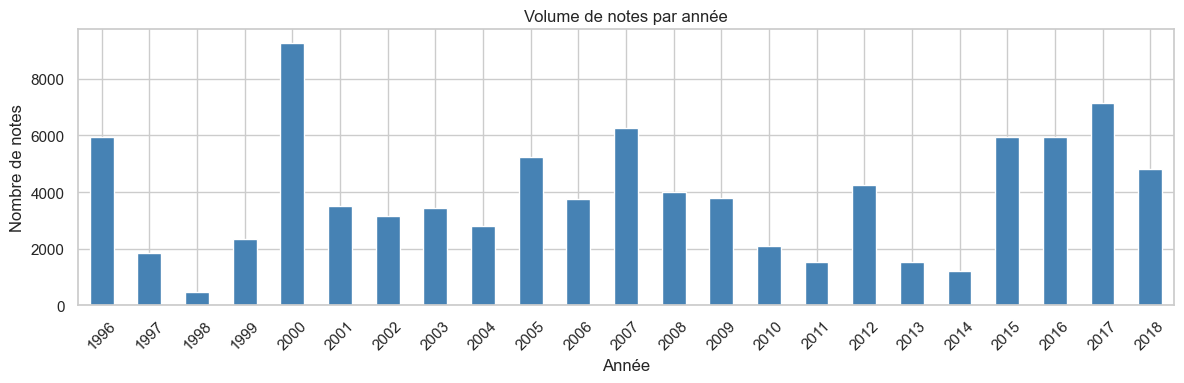

In [19]:
ratings_tmp = ratings.copy()
ratings_tmp["date"] = pd.to_datetime(ratings_tmp["timestamp"], unit="s")
notes_par_an = ratings_tmp.groupby(ratings_tmp["date"].dt.year).size()

fig, ax = plt.subplots(figsize=(12, 4))
notes_par_an.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Volume de notes par année")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre de notes")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.9 Corrélations features utilisateurs

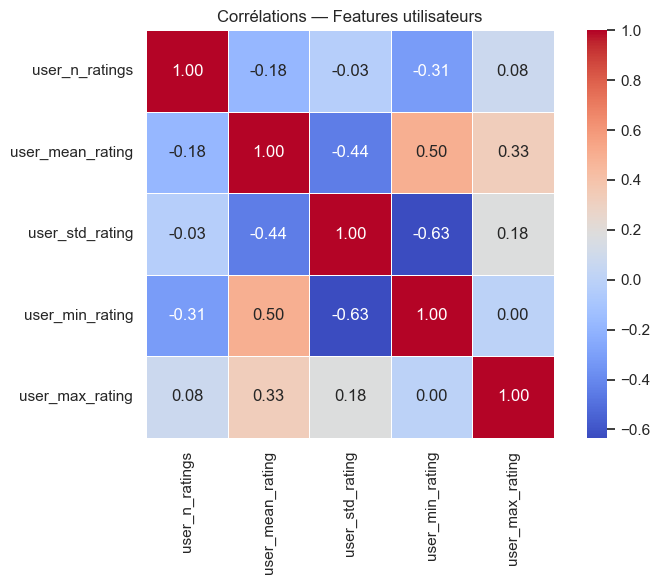

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    user_feats.drop(columns="userid").corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    ax=ax, square=True, linewidths=0.5,
)
ax.set_title("Corrélations — Features utilisateurs")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "user_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Log complet dans MLflow

In [21]:
with mlflow.start_run(run_name="EDA_full_analysis"):
    mlflow.log_metrics({k: v for k, v in summary.items() if isinstance(v, (int, float))})
    mlflow.log_metric("sparsity_pct", round(sparsity * 100, 4))
    mlflow.log_metric("user_avg_n_ratings", round(user_feats["user_n_ratings"].mean(), 3))
    mlflow.log_metric("item_avg_n_ratings", round(item_feats["item_n_ratings"].mean(), 3))
    for img in (PROJECT_DIR / "reports").glob("*.png"):
        mlflow.log_artifact(str(img))
    logger.success("EDA complète loggée dans MLflow")

print("→ Visualiser avec : mlflow ui --backend-store-uri sqlite:///mlflow.db")

2026-06-10 09:59:03 | SUCCESS  | EDA complète loggée dans MLflow


→ Visualiser avec : mlflow ui --backend-store-uri sqlite:///mlflow.db


## Résumé

| Métrique | Valeur |
|---|---|
| Notes brutes | 100 836 |
| Notes après filtre ≥5 | 90 274 (89,5 %) |
| Utilisateurs actifs | 610 |
| Films évalués (≥5 notes) | 3 650 / 9 742 |
| Densité de la matrice | 4,05 % |
| Note moyenne | 3,54 |
| Genres distincts | 20 |

**Prochaine étape** : entraîner les modèles avec `python src/trainer.py`